In [1]:
# Import dependencies
import os
import numpy as np
from matplotlib import pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.utils import img_to_array, array_to_img

2025-05-16 07:28:06.832524: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-16 07:28:06.965990: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-05-16 07:28:06.966020: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2025-05-16 07:28:07.634256: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2025-

In [2]:
# from tensorflow.keras import mixed_precision

# # Set up mixed precision policies
# policy = mixed_precision.Policy('mixed_float16')
# mixed_precision.set_global_policy(policy)

## Select GPU and allow memory growth

```set_memory_growth = True``` allows for dynamic GPU memory allocation

In [3]:
# Select GPU we want to use
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# Set memory growth
physical_devices = tf.config.list_physical_devices('GPU') 
for gpu_instance in physical_devices: 
    tf.config.experimental.set_memory_growth(gpu_instance, True)
    

2025-05-16 07:28:08.468512: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2025-05-16 07:28:08.468560: W tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: UNKNOWN ERROR (303)
2025-05-16 07:28:08.468606: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:163] no NVIDIA GPU device is present: /dev/nvidia0 does not exist


## Get cifar10 dataset from keras

This is a dataset of 50,000 32x32 color training images and 10,000 test images, labeled over 10 categories. 

<table>
<thead>
<tr>
<th align="center">Label</th>
<th>Description</th>
</tr>
</thead>
<tbody>
<tr>
<td align="center">0</td>
<td>airplane</td>
</tr>
<tr>
<td align="center">1</td>
<td>car</td>
</tr>
<tr>
<td align="center">2</td>
<td>bird</td>
</tr>
<tr>
<td align="center">3</td>
<td>cat</td>
</tr>
<tr>
<td align="center">4</td>
<td>deer</td>
</tr>
<tr>
<td align="center">5</td>
<td>dog</td>
</tr>
<tr>
<td align="center">6</td>
<td>frog</td>
</tr>
<tr>
<td align="center">7</td>
<td>horse</td>
</tr>
<tr>
<td align="center">8</td>
<td>ship</td>
</tr>
<tr>
<td align="center">9</td>
<td>truck</td>
</tr>
</tbody>
</table>

In [4]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
# we check the dataset shape
assert x_train.shape == (50000, 32, 32, 3)
assert x_test.shape == (10000, 32, 32, 3)
assert y_train.shape == (50000, 1)
assert y_test.shape == (10000, 1)

In [5]:
# Dictionary containg the sematic classes
label_dict = {0:"airplane", 1:"car", 2:"bird", 3:"cat", 4:"deer", 5:"dog", 6:"frog", 7:"horse", 8:"ship", 9:"truck"}

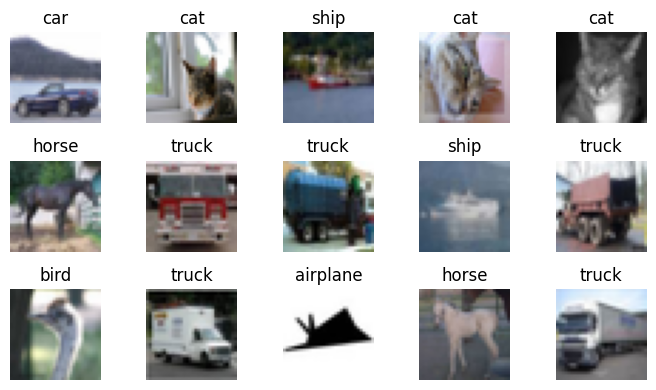

In [6]:
# Show 15 example images from test dataset.
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(7, 4))
ax = axes.ravel()

ids = np.random.randint(1, 10000, size=15)
for i, j in enumerate(ids):
    
    ax[i].imshow(x_test[j])
    ax[i].set_title(label_dict[y_test[j][0]])
    ax[i].axis("off")

plt.tight_layout()
plt.show()

In [7]:
### choose part of the image to reduce calculation time
ids = np.random.randint(1, 50000, size=5000)
x_train, y_train = x_train[ids], y_train[ids]

ids = np.random.randint(1, 10000, size=1000)
x_test, y_test = x_test[ids], y_test[ids]

### check range of image intensity and normalize  

In [8]:
print(np.min(x_train), np.max(x_train))

x_train = x_train / 255.
x_test = x_test / 255.

print(np.min(x_train), np.max(x_train))

0 255
0.0 1.0


### Machine Learning based classification

In [9]:
! pip install SimpleITK
! pip install pyradiomics
import SimpleITK as sitk

from radiomics import featureextractor

In [10]:
# import warnings

# def fxn():
#     warnings.warn("deprecated", DeprecationWarning)

# with warnings.catch_warnings():
#     warnings.simplefilter("ignore")
#     fxn()
import logging
logger = logging.getLogger("radiomics.glcm")
logger.setLevel(logging.ERROR)

In [11]:
from tqdm import tqdm

In [23]:
extractor = featureextractor.RadiomicsFeatureExtractor()
extractor.disableAllFeatures()
extractor.enableFeatureClassByName('firstorder')
extractor.enableFeatureClassByName('glcm') 
im_shape = x_train.shape

mask = np.ones(im_shape[1:])
mask = sitk.GetImageFromArray(mask)

features_train = []
for i in tqdm(range(im_shape[0])):
    
    features = extractor.computeFeatures(sitk.GetImageFromArray(x_train[i, :, :, :]), mask, 'original')
    features_all = []
    for featureName in features.keys():
        val = features[featureName]
        features_all = np.append(features_all, val/(1e-8+np.max(val)))
        
    features_train.append(features_all)

features_train = np.row_stack(features_train)
features_train.shape


100%|██████████| 5000/5000 [00:33<00:00, 149.73it/s]


(5000, 42)

In [24]:
features_test = []
for i in tqdm(range(x_test.shape[0])):
    
    features = extractor.computeFeatures(sitk.GetImageFromArray(x_test[i, :, :, :]), mask, 'original')
    features_all = []
    for featureName in features.keys():
        val = features[featureName]
        features_all = np.append(features_all, val/(1e-8+np.max(val)))
        
    features_test.append(features_all)
features_test = np.row_stack(features_test)
features_test.shape

100%|██████████| 1000/1000 [00:06<00:00, 149.79it/s]


(1000, 42)

In [26]:
### build classification model with Linear discriminant analysis

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

model_LDA = LDA().fit(features_train, y_train)
y_pred = model_LDA.predict(features_test)

/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:1111: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [27]:
from sklearn.metrics import confusion_matrix
cmat = confusion_matrix(y_test, y_pred)
cmat

array([[ 0,  5, 23,  5,  8,  0,  5,  3, 53, 10],
       [ 0, 27,  3, 19,  1,  1, 12,  0, 11, 10],
       [ 0,  7, 22, 16, 16,  0, 15,  0, 15,  7],
       [ 0, 21,  6, 30,  7,  2,  8,  3, 15, 15],
       [ 0,  5, 25, 22, 27,  0, 24,  1,  8,  3],
       [ 0, 11, 12, 21,  9,  0,  5,  3, 13, 16],
       [ 0, 15,  9, 14,  9,  0, 30,  0, 10,  9],
       [ 0, 12,  8, 14,  5,  0,  9,  5, 18, 21],
       [ 0,  9, 16, 14,  7,  0,  1,  2, 40, 20],
       [ 0, 18,  0, 11,  0,  1,  7,  3, 19, 38]])

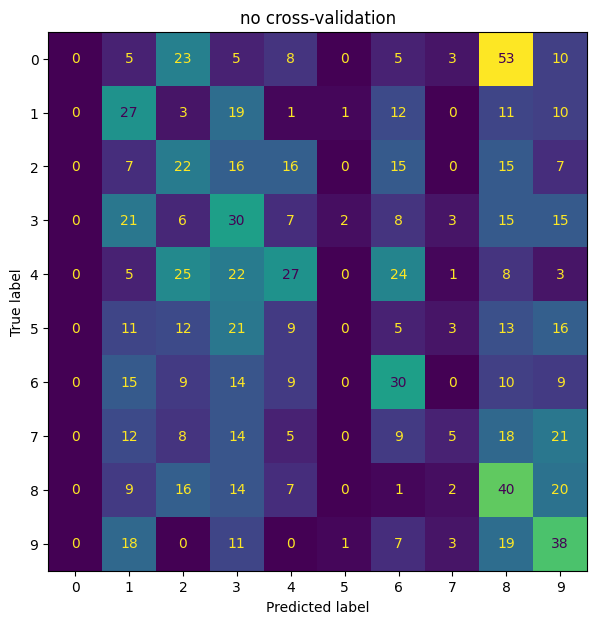

In [29]:
### display confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cmat, display_labels=np.unique(y_train))
    
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
disp.plot(ax=ax, colorbar=False)
plt.title('Machine Learning')
plt.show()

In [30]:
# Define a simple model using keras sequential

def gen_model(input_size, output_size):
    
    model = tf.keras.Sequential([
            keras.Input(shape=input_size),   # set input shape
        
            keras.layers.Conv2D(64, 3),      # include 2D convolutions, conv2d(n_kernels, size)
            keras.layers.Conv2D(64, 3),
            keras.layers.Conv2D(64, 3),
        
            keras.layers.Flatten(),          # reshape to 1D vector
        
            keras.layers.Dense(256, activation='relu'),  # Dense layer with 256 outputs, no linear activation
            keras.layers.Dense(output_size, activation='softmax')  # output layer with 10 outputs
        ])
    return model

In [31]:
input_size = (32, 32, 3)
output_size = 10
learning_rate = 0.001

model = gen_model(input_size, output_size)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate), 
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['sparse_categorical_accuracy'])

In [ ]:
model.fit(x_train, y_train, 
          batch_size=None,
          epochs=10,
          verbose=1,     # 0-no output, 1-progress bar, 2-one line per epoch
          validation_data=None,
          validation_split=0.2,
          callbacks=None,
          shuffle=True
         )

Epoch 1/10
 25/125 [=====>........................] - ETA: 25s - loss: 0.1275 - sparse_categorical_accuracy: 0.9650

In [ ]:
prediction = model.predict(x_test)
print("prediction shape : ", np.shape(prediction))

prediction_class = np.argmax(prediction, axis=-1)
print("prediction_class shape", np.shape(prediction_class))

In [ ]:
cmat_DL = confusion_matrix(y_test, prediction_class)
cmat_DL

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cmat_DL, display_labels=np.unique(y_train))
    
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
disp.plot(ax=ax, colorbar=False)
plt.title('Deep Learning')
plt.show()